In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
%matplotlib inline

In [6]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/2. Encoding/One-Hot Encoding.csv")

In [7]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Other,Developer_Sega,Developer_Square Enix,Developer_THQ,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts
0,Spider-Man: Mysterio's Menace,7.10189,0.61,0.43,0.00,0.16,0.01,2001,False,False,...,False,False,False,False,False,False,False,False,True,False
1,Tomb Raider Chronicles,7.10189,0.61,0.34,0.00,0.23,0.04,2000,False,False,...,True,False,False,False,False,False,False,False,False,False
2,Tony Hawk: RIDE,4.50000,0.61,0.38,0.00,0.15,0.08,2009,False,False,...,True,False,False,False,False,False,False,False,False,False
3,Advance Wars: Days of Ruin,8.40000,0.61,0.43,0.00,0.13,0.05,2008,False,False,...,True,False,False,False,False,False,False,False,False,False
4,New Play Control! Pikmin 2,8.70000,0.61,0.11,0.34,0.13,0.02,2012,False,False,...,True,False,False,False,False,False,False,False,False,False


In [8]:
df.dtypes # check data types

Game Title                      object
Critic Score                   float64
Sales                          float64
North American Sales           float64
Japanese Sales                 float64
                                ...   
Developer_Ubisoft                 bool
Developer_Ubisoft Montreal        bool
Developer_Unknown                 bool
Developer_Vicarious Visions       bool
Developer_Visual Concepts         bool
Length: 125, dtype: object

In [9]:
# Create decade column
df['Decade'] = (df['Release Year'] // 10) * 10

# Percentages of sales per region 
df['NA Share'] = df['North American Sales'] / df['Sales']
df['EU Share'] = df['EU Sales'] / df['Sales']
df['JP Share'] = df['Japanese Sales'] / df['Sales']
df['Other Share'] = df['Other Sales'] / df['Sales']

# New Game ?
df['Is Recent'] = df['Release Year'].apply(lambda x: 1 if x >= 2015 else 0)

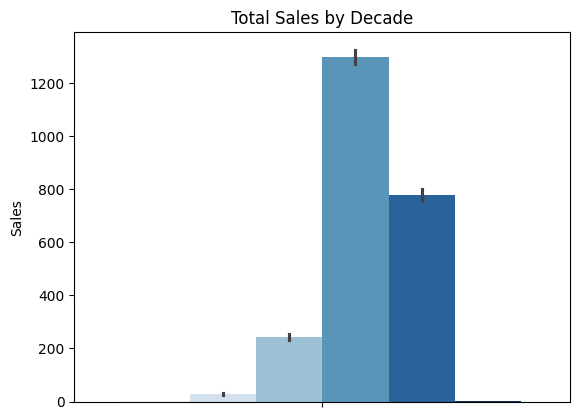

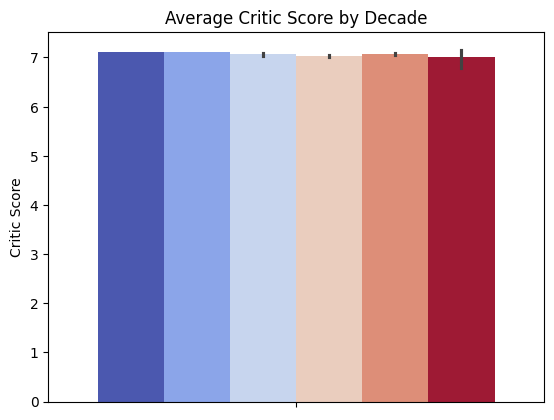

In [10]:
# Check sales trends across decades

sns.barplot(hue="Decade", y="Sales", data=df, estimator="sum", palette="Blues", legend=False)
plt.title("Total Sales by Decade")
plt.show()

sns.barplot(hue="Decade", y="Critic Score", data=df, estimator="mean", palette="coolwarm", legend=False)
plt.title("Average Critic Score by Decade")
plt.show()

In [11]:
# Bins and labels
bins = [0, 3, 7, 10]          # cut points
labels = ["Low", "Medium", "High"] # category names

# New Game Quality column 
df["Game Quality"] = pd.cut(df["Critic Score"], bins=bins, labels=labels, include_lowest=True)

# Label Encode categories as integers
encoding_map = {"Low": 0, "Medium": 1, "High": 2}
df["Game Quality Encoded"] = df["Game Quality"].map(encoding_map)

# check
print(df[["Critic Score", "Game Quality", "Game Quality Encoded"]].head(20))

    Critic Score Game Quality Game Quality Encoded
0        7.10189         High                    2
1        7.10189         High                    2
2        4.50000       Medium                    1
3        8.40000         High                    2
4        8.70000         High                    2
5        7.10189         High                    2
6        8.90000         High                    2
7        9.00000         High                    2
8        7.10189         High                    2
9        7.10189         High                    2
10       7.10189         High                    2
11       7.10189         High                    2
12       7.10189         High                    2
13       7.10189         High                    2
14       7.10189         High                    2
15       6.40000       Medium                    1
16       7.10189         High                    2
17       8.60000         High                    2
18       7.10189         High  

In [12]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Spider-Man: Mysterio's Menace,7.10189,0.61,0.43,0.00,0.16,0.01,2001,False,False,...,True,False,2000,0.704918,0.262295,0.000000,0.016393,0,High,2
1,Tomb Raider Chronicles,7.10189,0.61,0.34,0.00,0.23,0.04,2000,False,False,...,False,False,2000,0.557377,0.377049,0.000000,0.065574,0,High,2
2,Tony Hawk: RIDE,4.50000,0.61,0.38,0.00,0.15,0.08,2009,False,False,...,False,False,2000,0.622951,0.245902,0.000000,0.131148,0,Medium,1
3,Advance Wars: Days of Ruin,8.40000,0.61,0.43,0.00,0.13,0.05,2008,False,False,...,False,False,2000,0.704918,0.213115,0.000000,0.081967,0,High,2
4,New Play Control! Pikmin 2,8.70000,0.61,0.11,0.34,0.13,0.02,2012,False,False,...,False,False,2010,0.180328,0.213115,0.557377,0.032787,0,High,2


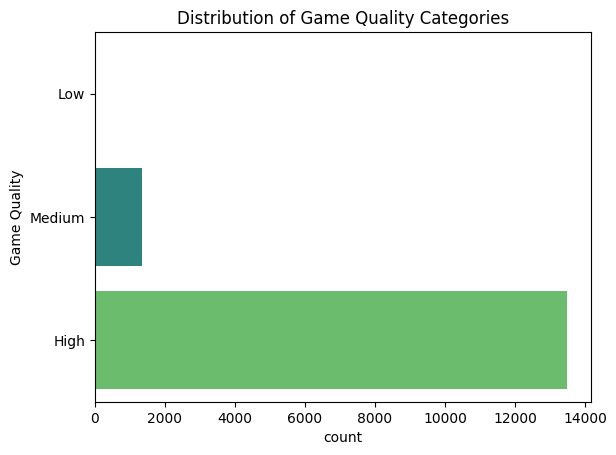

In [13]:
# Distribution of Game Quality

sns.countplot(hue="Game Quality", y="Game Quality", data=df, palette="viridis", legend=False)
plt.title("Distribution of Game Quality Categories")
plt.show()

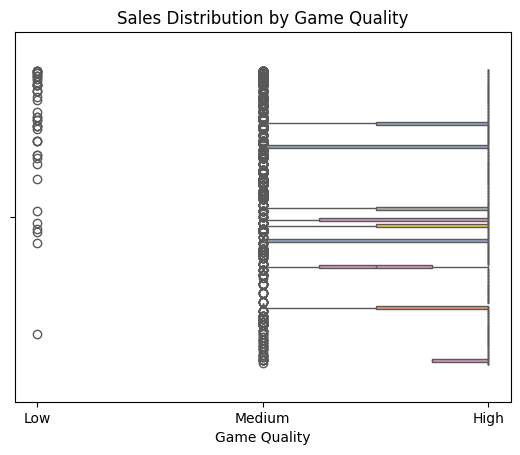

In [14]:
sns.boxplot(x="Game Quality", hue="Sales", data=df, palette="Set2", legend=False)
plt.title("Sales Distribution by Game Quality")
plt.show()

In [15]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/3. Feature Engineering/Ft Engineering(One-Hot).csv", index=False)